# 다이캐스팅 품질 예측 프로젝트 (End-to-End, XGBoost)

이 노트북은 **비전공자도 이해할 수 있도록** 설명을 최대한 자세히 적어둔 완성형 분석 파이프라인입니다.

## 목표
1. 데이터를 불러오고(컬럼 구조 이해)
2. 불량(Defects)을 **표면/구조 그룹**으로 묶어 **Multi-label 타겟(y)**을 만든 뒤
3. 공정(Process) + 센서(Sensor) 변수로 **XGBoost 모델**을 학습합니다.
4. **데이터 누출(leakage)** 위험이 있는 컬럼을 자동으로 제거하여 **신뢰도 있는 모델**을 만듭니다.
5. Feature importance / (선택) SHAP / “불량 최소 조건” 탐색까지 이어집니다.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# XGBoost (설치가 안 되어 있으면 아래 주석을 해제 후 실행)
# !pip -q install xgboost
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 1. 데이터 로드

이 프로젝트에서는 `product_type_1.csv`를 사용합니다.

이 CSV는 **2줄 헤더(MultiIndex)** 구조일 수 있습니다.
- 상위 레벨: process / sensor / defects
- 하위 레벨: velocity_1, bubble_1 등

그래서 `header=[0,1]`로 먼저 읽어보고,
- MultiIndex면 그대로 사용
- 아니면 일반 컬럼(flat)으로 처리합니다.


In [4]:
DATA_PATH = "product_type_1.csv"

try:
    df1 = pd.read_csv(DATA_PATH, header=[0, 1])
    multi = True
except Exception:
    df1 = pd.read_csv(DATA_PATH)
    multi = False

print("MultiIndex header:", multi)
print("Shape:", df1.shape)

if multi:
    print("Top-level columns:", df1.columns.levels[0].tolist())
else:
    print("Columns sample:", df1.columns[:15].tolist())

df1.head()


MultiIndex header: True
Shape: (2653, 42)
Top-level columns: ['defect_flag', 'defects', 'process', 'sensor']


process                                                                                                                                                                                     \
       id product_type shot velocity_1 velocity_2 velocity_3 high_velocity cylinder_pressure rapid_rise_time biscuit_thickness clamping_force cycle_time pressure_rise_time casting_pressure   
0       1            1    1      0.144      0.170      0.188         2.134               214           0.008                10            258       20.7              0.044             1037   
1    1002            1    2      0.144      0.170      0.182         2.124               217           0.008                11            257       20.7              0.044             1052   
2    2003            1    3      0.144      0.170      0.182         2.116               214           0.008                11            257       20.8              0.041             1037   
3    3004            1    4      0.144      0.170      0.182         2.137               217           0.008                11            257       20.7              0.043             1051   
4    4005            1    5      0.144      0.172      0.176         2.111               217           0.008                12            257       20.7              0.042             1052   

                                                     sensor                                                                                                                              \
  spray_time spray_1_time spray_2_time melting_furnace_temp air_pressure air_pressure_min air_pressure_max coolant_temp coolant_temp_min coolant_temp_max coolant_pressure factory_temp   
0        7.8          0.7          0.8                695.0          6.3                3                9         26.0               10               50             2.71         32.9   
1        7.8          0.7          0.8                696.4          6.3                3                9         26.1               10               50             2.69         32.9   
2        7.8          0.7          0.8                696.4          6.3                3                9         26.1               10               50             2.69         32.9   
3        7.8          0.7          0.8                696.4          6.3                3                9         26.1               10               50             2.69         32.9   
4        7.8          0.7          0.8                697.9          6.4                3                9         26.1               10               50             2.69         32.9   

                                                                                                    defects                                                                                          \
  factory_temp_min factory_temp_max factory_humidity factory_humidity_min factory_humidity_max short_shot_1 bubble_1 exfoliation_1 stain_1 dent_1 deformation_1 short_shot_2 bubble_2 exfoliation_2   
0             18.0             22.0             58.4                 18.0                 22.0            0        0             0       0      0             0            0        0             0   
1             18.0             22.0             58.2                 18.0                 22.0            0        0             0       0      0             0            0        0             0   
2             18.0             22.0             58.2                 18.0                 22.0            0        0             0       0      0             0            0        0             0   
3             18.0             22.0             58.2                 18.0                 22.0            0        0             1       0      0             0            0        0             0   
4             18.0             22.0             57.8                 18.0                 22.0            0        0             0       0      0        

## 2. process / sensor / defects 블록 분리

- MultiIndex라면 `df1['process']` 처럼 접근 가능
- flat 컬럼이라면 `process_...`, `sensor_...`, `defects_...` 접두어로 찾아 분리

아래 코드는 두 경우를 모두 안전하게 처리합니다.


In [5]:
def is_multiindex_columns(df: pd.DataFrame) -> bool:
    return isinstance(df.columns, pd.MultiIndex)

def get_block(df: pd.DataFrame, block_name: str) -> pd.DataFrame:
    if is_multiindex_columns(df):
        return df[block_name].copy()
    prefix = block_name.lower() + "_"
    cols = [c for c in df.columns if str(c).lower().startswith(prefix)]
    return df[cols].copy()

process_df = get_block(df1, "process")
sensor_df  = get_block(df1, "sensor")
defects_df = get_block(df1, "defects")

print("process_df:", process_df.shape)
print("sensor_df :", sensor_df.shape)
print("defects_df:", defects_df.shape)
print("\n[defects columns]")
print(defects_df.columns.tolist())


process_df: (2653, 17)
sensor_df : (2653, 14)
defects_df: (2653, 10)

[defects columns]
['short_shot_1', 'bubble_1', 'exfoliation_1', 'stain_1', 'dent_1', 'deformation_1', 'short_shot_2', 'bubble_2', 'exfoliation_2', 'deformation_2']


## 3. defect 그룹화 → multi-label 타겟(y) 만들기

우리가 예측할 y는 2개입니다.

- **표면**: dent/stain/exfoliation 중 하나라도 있으면 1
- **구조**: short_shot/bubble/deformation 중 하나라도 있으면 1

주의:
- defects 값이 0/1 뿐 아니라 2,3도 있을 수 있으므로
  - **0이면 양품**
  - **0초과면 불량(1로 통일)**
  로 이진화합니다.


In [6]:
defects_numeric = defects_df.apply(pd.to_numeric, errors="coerce").fillna(0)
defects_bin = (defects_numeric > 0).astype(int)

defect_groups = {
    "표면": ["dent_1", "stain_1", "exfoliation_1", "exfoliation_2"],
    "구조": ["short_shot_1", "short_shot_2", "bubble_1", "bubble_2", "deformation_1", "deformation_2"],
}

def normalize_defect_colname(col):
    s = str(col).lower()
    return s.replace("defects_", "") if s.startswith("defects_") else s

map_to_real = {normalize_defect_colname(c): c for c in defects_bin.columns}

y = pd.DataFrame(index=df1.index)
for group_name, cols in defect_groups.items():
    real_cols = [map_to_real[c] for c in cols if c in map_to_real]
    if len(real_cols) == 0:
        raise KeyError(f"[{group_name}] 그룹에 해당하는 defects 컬럼을 찾지 못했습니다: {cols}")
    y[group_name] = defects_bin[real_cols].any(axis=1).astype(int)

print("[표면/구조 불량 비율(%)]")
display((y.mean() * 100).round(2).to_frame("rate_%"))
y.head()


[표면/구조 불량 비율(%)]


,rate_%
표면,7.84
구조,14.59


,표면,구조
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0


## 4. X 만들기 + 데이터 누출(leakage) 방지

X는 **process + sensor**만 사용합니다.

그리고 아래는 “미래 예측에서 알 수 없거나”, “식별자/시간”이라서  
모델이 **공정 원인이 아니라 꼼수 패턴을 외우게** 만들 수 있습니다.

- process_id: 단순 식별번호
- process_shot: 생산 순서/카운터(시간 변수 성격)
- process_product_type: 이번 분석에서는 product_type_1만 사용 → 불필요/혼입 위험
- defect_flag_is_defect / is_defect: 이름부터 정답 힌트 가능

그래서 이런 컬럼을 **자동 탐지해서 제거**합니다.


In [7]:
X = pd.concat([process_df, sensor_df], axis=1).copy()
print("X shape (before drop):", X.shape)

def col_to_str(c):
    if isinstance(c, tuple):
        return "_".join([str(x) for x in c]).lower()
    return str(c).lower()

leak_keywords = [
    "process_id",
    "process_shot",
    "process_product_type",
    "defect_flag_is_defect",
    "is_defect",
]

leak_cols = [c for c in X.columns if any(k in col_to_str(c) for k in leak_keywords)]
if leak_cols:
    print("🚫 drop leakage cols:", leak_cols)
    X = X.drop(columns=leak_cols, errors="ignore")
else:
    print("✅ leakage 키워드 컬럼 없음")

defect_like = [c for c in X.columns if "defects" in col_to_str(c)]
if defect_like:
    print("🚫 drop defects-like cols from X:", defect_like)
    X = X.drop(columns=defect_like, errors="ignore")

print("X shape (after drop):", X.shape)


X shape (before drop): (2653, 31)
✅ leakage 키워드 컬럼 없음
X shape (after drop): (2653, 31)


## 5. Train/Test 분리 (multi-label stratify)

y가 (표면, 구조) 2개 컬럼이므로 `stratify=y`를 그대로 쓰면 오류가 나거나 불안정할 수 있습니다.

그래서 (표면,구조) 조합을 문자열로 만들어 strata로 사용합니다.
- 00, 10, 01, 11 같은 형태


In [8]:
strata = y.astype(str).agg("".join, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strata
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

print("\n[라벨 조합 분포(전체)]")
display(strata.value_counts(normalize=True).sort_index().to_frame("ratio"))


X_train: (2122, 31) X_test: (531, 31)
y_train: (2122, 2) y_test: (531, 2)

[라벨 조합 분포(전체)]


,ratio
00,0.782887
01,0.138711
10,0.071240
11,0.007162


## 6. XGBoost 모델 학습 (표면/구조 각각 1개 모델)

Multi-label이지만, 타겟(표면/구조)마다 불량 비율이 달라서  
타겟별로 `scale_pos_weight = (양품 수 / 불량 수)`를 따로 적용합니다.

평가 지표:
- ROC-AUC
- PR-AUC (불균형에서 특히 중요)
- precision / recall / f1


In [9]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

models, preds, probas = {}, {}, {}

for t in y_train.columns:
    neg = int((y_train[t] == 0).sum())
    pos = int((y_train[t] == 1).sum())
    spw = float(neg / max(pos, 1))
    print(f"\n[{t}] scale_pos_weight = {spw:.3f} (neg={neg}, pos={pos})")

    model = XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_lambda=1.0,
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imp, y_train[t])

    proba = model.predict_proba(X_test_imp)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    models[t] = model
    probas[t] = proba
    preds[t]  = pred

    print(classification_report(y_test[t], pred, digits=4))
    roc = roc_auc_score(y_test[t], proba)
    pr  = average_precision_score(y_test[t], proba)
    print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")

y_pred  = pd.DataFrame(preds, index=y_test.index)
y_proba = pd.DataFrame(probas, index=y_test.index)

display(y_pred.head())
display(y_proba.head())



[표면] scale_pos_weight = 11.783 (neg=1956, pos=166)
              precision    recall  f1-score   support

           0     0.9252    0.9611    0.9428       489
           1     0.1739    0.0952    0.1231        42

    accuracy                         0.8927       531
   macro avg     0.5496    0.5282    0.5330       531
weighted avg     0.8658    0.8927    0.8780       531

ROC-AUC: 0.7029 | PR-AUC: 0.1780

[구조] scale_pos_weight = 5.845 (neg=1812, pos=310)
              precision    recall  f1-score   support

           0     0.8763    0.9053    0.8906       454
           1     0.3065    0.2468    0.2734        77

    accuracy                         0.8098       531
   macro avg     0.5914    0.5760    0.5820       531
weighted avg     0.7937    0.8098    0.8011       531

ROC-AUC: 0.7185 | PR-AUC: 0.3220


,표면,구조
2638,0,0
2088,0,0
2631,0,0
2249,0,0
1608,0,0


,표면,구조
2638,0.000101,0.000439
2088,0.048229,0.000225
2631,0.000294,0.000344
2249,0.000627,0.007798
1608,0.008220,0.003705


## 7. (선택) Threshold 튜닝

현재는 확률이 0.5 이상이면 불량이라고 판단합니다.

불량이 적은 데이터에서는 0.5가 너무 높아서 불량을 많이 놓칠 수 있으니,  
0.05~0.80 구간에서 threshold를 바꿔가며 precision/recall trade-off를 확인합니다.



=== [표면] threshold sweep (recall 높은 순 TOP5) ===


,threshold,precision_1,recall_1,f1_1,accuracy
0,0.05,0.139535,0.428571,0.210526,0.745763
1,0.10,0.152174,0.333333,0.208955,0.800377
2,0.15,0.135135,0.238095,0.172414,0.819209
3,0.20,0.175439,0.238095,0.202020,0.851224
4,0.25,0.170213,0.190476,0.179775,0.862524


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


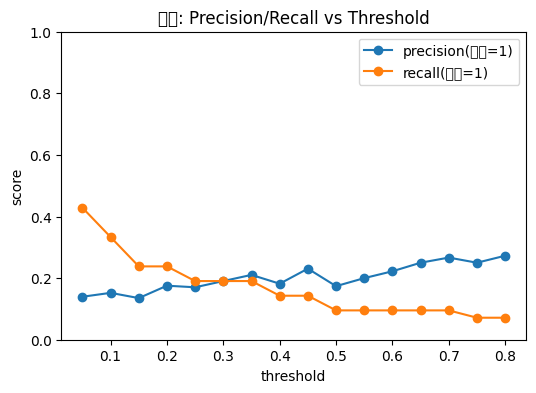


=== [구조] threshold sweep (recall 높은 순 TOP5) ===


,threshold,precision_1,recall_1,f1_1,accuracy
0,0.05,0.235556,0.688312,0.350993,0.630885
1,0.10,0.254237,0.584416,0.354331,0.691149
2,0.15,0.268456,0.519481,0.353982,0.725047
3,0.20,0.289062,0.480519,0.360976,0.753296
4,0.25,0.306306,0.441558,0.361702,0.774011


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


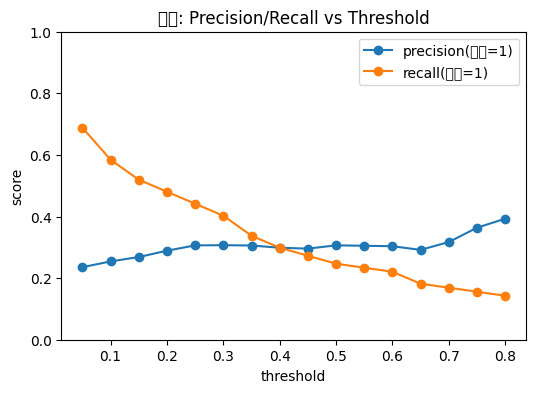

In [10]:
def evaluate_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    rep = classification_report(y_true, pred, output_dict=True, zero_division=0)
    return {
        "threshold": threshold,
        "precision_1": rep["1"]["precision"],
        "recall_1": rep["1"]["recall"],
        "f1_1": rep["1"]["f1-score"],
        "accuracy": rep["accuracy"]
    }

for t in y_test.columns:
    rows = []
    for th in np.linspace(0.05, 0.80, 16):
        rows.append(evaluate_threshold(y_test[t].values, y_proba[t].values, float(th)))
    df_th = pd.DataFrame(rows)

    print(f"\n=== [{t}] threshold sweep (recall 높은 순 TOP5) ===")
    display(df_th.sort_values("recall_1", ascending=False).head(5))

    plt.figure(figsize=(6,4))
    plt.plot(df_th["threshold"], df_th["precision_1"], marker="o", label="precision(불량=1)")
    plt.plot(df_th["threshold"], df_th["recall_1"], marker="o", label="recall(불량=1)")
    plt.title(f"{t}: Precision/Recall vs Threshold")
    plt.xlabel("threshold")
    plt.ylabel("score")
    plt.ylim(0, 1.0)
    plt.legend()
    plt.show()


## 8. Feature Importance

XGBoost는 각 변수의 중요도를 제공합니다.  
중요도가 높다고 “원인”이라고 단정할 수는 없지만,  
공정 점검/최적화 후보를 고르는 데 매우 유용합니다.



=== [표면] TOP 15 Feature Importance ===


,importance
spray_time,0.089682
id,0.076491
shot,0.055593
coolant_temp,0.051004
spray_1_time,0.050707
biscuit_thickness,0.048263
factory_temp,0.047030
velocity_1,0.046925
coolant_pressure,0.046735
factory_humidity,0.046644


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


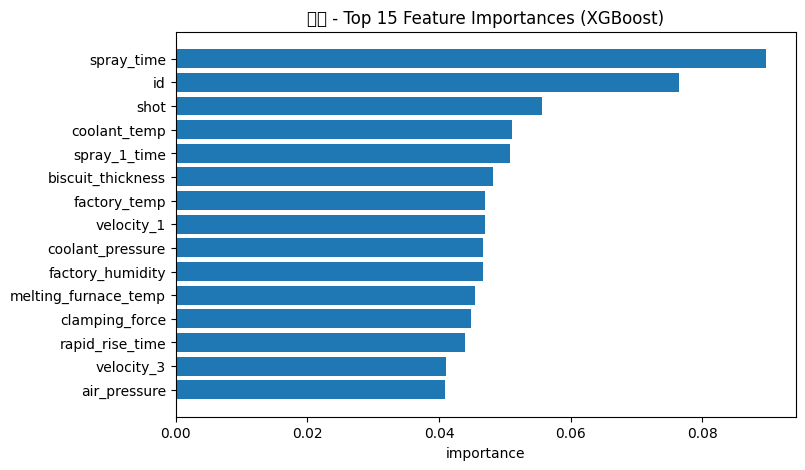


=== [구조] TOP 15 Feature Importance ===


,importance
factory_humidity,0.121557
id,0.080859
biscuit_thickness,0.052987
factory_temp,0.050201
spray_time,0.046482
shot,0.045256
clamping_force,0.044880
melting_furnace_temp,0.044714
air_pressure,0.044330
velocity_2,0.043164


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


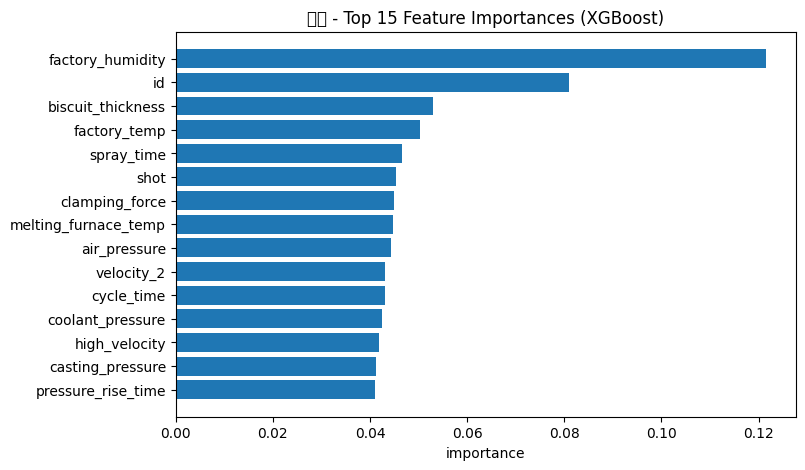

In [11]:
for t, model in models.items():
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(f"\n=== [{t}] TOP 15 Feature Importance ===")
    display(imp.head(15).to_frame("importance"))

    plt.figure(figsize=(8,5))
    topk = imp.head(15)[::-1]
    plt.barh(topk.index.astype(str), topk.values)
    plt.title(f"{t} - Top 15 Feature Importances (XGBoost)")
    plt.xlabel("importance")
    plt.show()


## 9. “불량 최소 조건” 탐색

중요도 TOP 변수들을 10분위(Decile)로 나눠 구간별 불량률을 계산합니다.

- 어떤 구간에서 불량률이 가장 낮은지 확인
- 공정 조건 최적화 후보를 좁히는 데 도움

주의: 이것은 인과가 아니라 패턴입니다.


In [12]:
TOP_N = 5

for t, model in models.items():
    print(f"\n=== [{t}] 불량 최소 조건 탐색 (TOP {TOP_N}) ===")
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    top_vars = imp.head(TOP_N).index.tolist()

    df_tmp = X_test.copy()
    df_tmp["y_true"] = y_test[t].values

    rows = []
    for v in top_vars:
        try:
            bins = pd.qcut(df_tmp[v], q=10, duplicates="drop")
            rate = df_tmp.groupby(bins)["y_true"].mean()
            rows.append({
                "var": str(v),
                "best_bin": str(rate.idxmin()),
                "best_defect_rate": float(rate.min())
            })
        except Exception as e:
            rows.append({
                "var": str(v),
                "best_bin": "N/A",
                "best_defect_rate": np.nan,
                "note": repr(e)
            })

    display(pd.DataFrame(rows))



=== [표면] 불량 최소 조건 탐색 (TOP 5) ===


/tmp/ipykernel_179/189318272.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_tmp.groupby(bins)["y_true"].mean()
/tmp/ipykernel_179/189318272.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_tmp.groupby(bins)["y_true"].mean()
/tmp/ipykernel_179/189318272.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_tmp.groupby(bins)["y_true"].mean()
/tmp/ipykernel_179/189318272.py:15: FutureW

,var,best_bin,best_defect_rate
0,spray_time,"(8.4, 9.7]",0.0
1,id,"(2813942.0, 3330255.0]",0.0
2,shot,"(648.0, 758.0]",0.0
3,coolant_temp,"(26.9, 27.1]",0.0
4,spray_1_time,"(1.0, 1.2]",0.0



=== [구조] 불량 최소 조건 탐색 (TOP 5) ===


/tmp/ipykernel_179/189318272.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_tmp.groupby(bins)["y_true"].mean()
/tmp/ipykernel_179/189318272.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_tmp.groupby(bins)["y_true"].mean()
/tmp/ipykernel_179/189318272.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df_tmp.groupby(bins)["y_true"].mean()
/tmp/ipykernel_179/189318272.py:15: FutureW

,var,best_bin,best_defect_rate
0,factory_humidity,"(68.9, 70.6]",0.000000
1,id,"(3330255.0, 3771195.0]",0.000000
2,biscuit_thickness,"(13.0, 22.0]",0.027778
3,factory_temp,"(32.0, 32.2]",0.033898
4,spray_time,"(8.4, 9.7]",0.000000


## 10. leakage 제거 최종 확인

아래 결과에 `shot`, `id`, `is_defect`, `defects` 관련 컬럼이 남아 있으면  
다시 X에서 제거해야 합니다.


In [13]:
[c for c in X.columns if "defect" in str(c).lower() or "shot" in str(c).lower() or "id" in str(c).lower()]


['id',
 'shot',
 'rapid_rise_time',
 'factory_humidity',
 'factory_humidity_min',
 'factory_humidity_max']